In [29]:
import os
import glob
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, AdaBoostClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, f1_score,
    classification_report, confusion_matrix, silhouette_score,
)

warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

RANDOM_STATE = 42  

ON_KAGGLE = os.path.exists("/kaggle/input")
OUT_DIR = "/kaggle/working" if ON_KAGGLE else "./outputs"
os.makedirs(OUT_DIR, exist_ok=True)

FILENAME = "social_media_screentime_mental_health_2026.csv"
if ON_KAGGLE:
    matches = glob.glob(f"/kaggle/input/**/{FILENAME}", recursive=True)
    DATA_PATH = matches[0] if matches else f"/kaggle/input/{FILENAME}"
else:
    DATA_PATH = FILENAME

print("Running on Kaggle:", ON_KAGGLE)
print("Data path:", DATA_PATH)
print("Output dir:", OUT_DIR)


Running on Kaggle: True
Data path: /kaggle/input/datasets/uditjain13/social-media-screen-time-and-mental-health-2026/social_media_screentime_mental_health_2026.csv
Output dir: /kaggle/working


In [30]:
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.dtypes


Shape: (7000, 25)


participant_id                          object
age                                      int64
gender                                  object
occupation                              object
region                                  object
most_used_platform                      object
platforms_used_count                     int64
daily_screen_hours                     float64
daily_notifications                      int64
night_time_use                          object
minutes_to_first_check_after_waking      int64
primary_purpose                         object
avg_sleep_hours                        float64
anxiety_score_0to27                      int64
low_mood_score_0to27                     int64
life_satisfaction_1to10                  int64
loneliness_1to10                         int64
self_esteem_1to10                        int64
fomo_1to10                               int64
social_comparison_1to10                  int64
physical_activity_days_per_week          int64
uses_screen_t

In [31]:
miss = df.isna().sum()
miss_pct = (miss / len(df) * 100).round(2)
miss_table = pd.DataFrame({"missing_count": miss, "missing_pct": miss_pct})
print("Missing values (only columns with any missing shown):")
print(miss_table[miss_table["missing_count"] > 0])

print("\nFully duplicate rows:", df.duplicated().sum())
print("Duplicate participant_id values:", df["participant_id"].duplicated().sum())


Missing values (only columns with any missing shown):
                 missing_count  missing_pct
gender                      70          1.0
avg_sleep_hours            105          1.5

Fully duplicate rows: 0
Duplicate participant_id values: 0


In [32]:
print(df["wellbeing_band"].value_counts())
print()
print((df["wellbeing_band"].value_counts(normalize=True) * 100).round(1).astype(str) + "%")


wellbeing_band
Moderate    3766
Good        2260
At-risk      974
Name: count, dtype: int64

wellbeing_band
Moderate    53.8%
Good        32.3%
At-risk     13.9%
Name: proportion, dtype: object


In [33]:
numeric_cols = df.select_dtypes(include="number").columns.tolist()
df[numeric_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
age,7000.0,29.246571,9.569132,13.0,22.0,29.0,36.0,71.0
platforms_used_count,7000.0,3.494571,1.763637,1.0,2.0,3.0,5.0,8.0
daily_screen_hours,7000.0,3.304971,1.881350,0.2,1.9,3.0,4.3,14.0
daily_notifications,7000.0,61.528286,54.879070,5.0,24.0,45.5,83.0,400.0
minutes_to_first_check_after_waking,7000.0,20.008286,13.976229,0.0,10.0,17.0,27.0,111.0
avg_sleep_hours,6895.0,6.964989,0.870575,3.8,6.4,7.0,7.6,10.0
anxiety_score_0to27,7000.0,11.378000,4.777726,0.0,8.0,11.0,14.0,27.0
low_mood_score_0to27,7000.0,3.845714,3.534197,0.0,0.0,3.0,6.0,19.0
life_satisfaction_1to10,7000.0,6.955857,1.614486,1.0,6.0,7.0,8.0,10.0
loneliness_1to10,7000.0,4.679286,2.094803,1.0,3.0,5.0,6.0,10.0


In [34]:
cat_cols = [c for c in df.select_dtypes(include="object").columns
            if c not in ("participant_id", "wellbeing_band")]
for c in cat_cols:
    print(f"--- {c} ({df[c].nunique()} unique) ---")
    print(df[c].value_counts(dropna=False))
    print()


--- gender (4 unique) ---
gender
Male                 3261
Female               3240
Non-binary            276
Prefer not to say     153
NaN                    70
Name: count, dtype: int64

--- occupation (6 unique) ---
occupation
Student               2715
Full-time employed    2285
Part-time employed     712
Self-employed          538
Unemployed             525
Retired                225
Name: count, dtype: int64

--- region (6 unique) ---
region
Asia             1959
North America    1842
Europe           1834
Latin America     670
Africa            425
Oceania           270
Name: count, dtype: int64

--- most_used_platform (8 unique) ---
most_used_platform
TikTok       1733
Instagram    1703
YouTube      1264
X/Twitter     585
Facebook      522
Snapchat      508
Reddit        411
LinkedIn      274
Name: count, dtype: int64

--- night_time_use (4 unique) ---
night_time_use
Sometimes      2616
Often          2086
Every night    1348
Never           950
Name: count, dtype: int64

--- 

In [35]:
for col in ["gender", "avg_sleep_hours"]:
    sub = df[df[col].isna()]["wellbeing_band"].value_counts(normalize=True).round(3)
    print(f"wellbeing_band distribution WHERE {col} is missing:")
    print(sub)
    print()
print("overall wellbeing_band distribution:")
print(df["wellbeing_band"].value_counts(normalize=True).round(3))


wellbeing_band distribution WHERE gender is missing:
wellbeing_band
Moderate    0.671
Good        0.214
At-risk     0.114
Name: proportion, dtype: float64

wellbeing_band distribution WHERE avg_sleep_hours is missing:
wellbeing_band
Moderate    0.467
Good        0.410
At-risk     0.124
Name: proportion, dtype: float64

overall wellbeing_band distribution:
wellbeing_band
Moderate    0.538
Good        0.323
At-risk     0.139
Name: proportion, dtype: float64


In [36]:
LEAKAGE_COLUMNS = ["anxiety_score_0to27", "low_mood_score_0to27"]

X_leak = df[LEAKAGE_COLUMNS]
y = df["wellbeing_band"]
Xtr, Xte, ytr, yte = train_test_split(X_leak, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y)

leak_tree = DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE)
leak_tree.fit(Xtr, ytr)
leak_acc = accuracy_score(yte, leak_tree.predict(Xte))
print(f"Held-out test accuracy using ONLY {LEAKAGE_COLUMNS}: {leak_acc:.4f}")

full_tree = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE)
full_tree.fit(X_leak, y)
print(f"\nTraining accuracy of this rule (fit on all data, depth=3): {full_tree.score(X_leak, y):.4f}")
print(export_text(full_tree, feature_names=LEAKAGE_COLUMNS))


Held-out test accuracy using ONLY ['anxiety_score_0to27', 'low_mood_score_0to27']: 1.0000

Training accuracy of this rule (fit on all data, depth=3): 1.0000
|--- anxiety_score_0to27 <= 9.50
|   |--- low_mood_score_0to27 <= 9.50
|   |   |--- class: Good
|   |--- low_mood_score_0to27 >  9.50
|   |   |--- low_mood_score_0to27 <= 16.50
|   |   |   |--- class: Moderate
|   |   |--- low_mood_score_0to27 >  16.50
|   |   |   |--- class: At-risk
|--- anxiety_score_0to27 >  9.50
|   |--- anxiety_score_0to27 <= 16.50
|   |   |--- low_mood_score_0to27 <= 16.50
|   |   |   |--- class: Moderate
|   |   |--- low_mood_score_0to27 >  16.50
|   |   |   |--- class: At-risk
|   |--- anxiety_score_0to27 >  16.50
|   |   |--- class: At-risk



In [37]:
other_psych = ["life_satisfaction_1to10", "loneliness_1to10", "self_esteem_1to10",
               "fomo_1to10", "social_comparison_1to10"]
X_other = df[other_psych]
Xtr2, Xte2, ytr2, yte2 = train_test_split(X_other, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y)
other_tree = DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)
other_tree.fit(Xtr2, ytr2)
other_acc = accuracy_score(yte2, other_tree.predict(Xte2))
print(f"Held-out accuracy using ONLY the other 5 psych scores: {other_acc:.4f}")
print("(majority-class baseline is ~0.538, for comparison)")


Held-out accuracy using ONLY the other 5 psych scores: 0.5291
(majority-class baseline is ~0.538, for comparison)


In [38]:
corr_cols = ["daily_screen_hours", "daily_notifications", "avg_sleep_hours",
             "minutes_to_first_check_after_waking", "physical_activity_days_per_week"]
df[corr_cols + ["anxiety_score_0to27"]].corr()["anxiety_score_0to27"].sort_values(ascending=False)


anxiety_score_0to27                    1.000000
daily_screen_hours                     0.523904
daily_notifications                    0.322232
minutes_to_first_check_after_waking    0.007966
physical_activity_days_per_week       -0.002501
avg_sleep_hours                       -0.256967
Name: anxiety_score_0to27, dtype: float64

In [39]:
NUMERIC_FEATURES = [
    "age", "platforms_used_count", "daily_screen_hours", "daily_notifications",
    "minutes_to_first_check_after_waking", "avg_sleep_hours",
    "life_satisfaction_1to10", "loneliness_1to10", "self_esteem_1to10",
    "fomo_1to10", "social_comparison_1to10", "physical_activity_days_per_week",
]

ORDINAL_FEATURES = {
    "night_time_use": ["Never", "Sometimes", "Often", "Every night"],
    "attempted_digital_detox": ["No", "Yes, failed", "Yes, succeeded"],
    "seeks_mental_health_support": ["No", "Considering it", "Yes"],
    "uses_screen_time_limits": ["No", "Yes"],
}

NOMINAL_FEATURES = ["gender", "occupation", "region", "most_used_platform", "primary_purpose"]

TARGET_CLASSES_ORDER = ["At-risk", "Moderate", "Good"]


def build_supervised_preprocessor():
    numeric_pipe = Pipeline([("impute", SimpleImputer(strategy="median"))])

    ordinal_cols = list(ORDINAL_FEATURES.keys())
    ordinal_categories = [ORDINAL_FEATURES[c] for c in ordinal_cols]
    ordinal_pipe = Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("encode", OrdinalEncoder(categories=ordinal_categories)),
    ])

    gender_pipe = Pipeline([
        ("impute", SimpleImputer(strategy="constant", fill_value="Unknown")),
        ("encode", OneHotEncoder(handle_unknown="ignore")),
    ])

    other_nominal_cols = [c for c in NOMINAL_FEATURES if c != "gender"]
    nominal_pipe = Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("encode", OneHotEncoder(handle_unknown="ignore")),
    ])

    return ColumnTransformer(
        transformers=[
            ("numeric", numeric_pipe, NUMERIC_FEATURES),
            ("ordinal", ordinal_pipe, ordinal_cols),
            ("gender", gender_pipe, ["gender"]),
            ("nominal", nominal_pipe, other_nominal_cols),
        ],
        remainder="drop",  # anything else (leakage cols, participant_id) is dropped even if present
    )


feature_cols = NUMERIC_FEATURES + list(ORDINAL_FEATURES.keys()) + NOMINAL_FEATURES
X = df[feature_cols].copy()
y = df["wellbeing_band"].copy()
print("Feature matrix shape:", X.shape)


Feature matrix shape: (7000, 21)


In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)
print(f"Train rows: {len(X_train)}   Test rows: {len(X_test)}")


Train rows: 5250   Test rows: 1750


In [41]:
def evaluate(name, pipeline, X_test, y_test, results_list):
    preds = pipeline.predict(X_test)
    acc = accuracy_score(y_test, preds)
    prec_macro, rec_macro, f1_macro, _ = precision_recall_fscore_support(
        y_test, preds, average="macro", zero_division=0
    )
    f1_weighted = f1_score(y_test, preds, average="weighted")

    print(f"\n{'-'*60}\n{name}\n{'-'*60}")
    print(f"Accuracy:        {acc:.4f}")
    print(f"Macro Precision: {prec_macro:.4f}")
    print(f"Macro Recall:    {rec_macro:.4f}")
    print(f"Macro F1:        {f1_macro:.4f}")
    print(f"Weighted F1:     {f1_weighted:.4f}")
    print("\nClassification report:")
    print(classification_report(y_test, preds, zero_division=0))
    cm = confusion_matrix(y_test, preds, labels=TARGET_CLASSES_ORDER)
    print("Confusion matrix (rows=actual, cols=predicted), order =", TARGET_CLASSES_ORDER)
    print(cm)

    results_list.append({
        "model": name, "accuracy": acc, "macro_precision": prec_macro,
        "macro_recall": rec_macro, "macro_f1": f1_macro, "weighted_f1": f1_weighted,
    })
    return cm


def plot_confusion(cm, name):
    fig, ax = plt.subplots(figsize=(4.5, 4))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(len(TARGET_CLASSES_ORDER))); ax.set_yticks(range(len(TARGET_CLASSES_ORDER)))
    ax.set_xticklabels(TARGET_CLASSES_ORDER); ax.set_yticklabels(TARGET_CLASSES_ORDER)
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual"); ax.set_title(name)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha="center", va="center",
                     color="white" if cm[i, j] > cm.max() / 2 else "black")
    fig.colorbar(im, fraction=0.046, pad=0.04)
    fig.tight_layout()
    plt.show()


results = []
cms = {}



------------------------------------------------------------
Decision Tree (baseline)
------------------------------------------------------------
Accuracy:        0.4417
Macro Precision: 0.4460
Macro Recall:    0.5092
Macro F1:        0.4368
Weighted F1:     0.4334

Classification report:
              precision    recall  f1-score   support

     At-risk       0.30      0.62      0.40       244
        Good       0.45      0.61      0.52       565
    Moderate       0.60      0.29      0.39       941

    accuracy                           0.44      1750
   macro avg       0.45      0.51      0.44      1750
weighted avg       0.51      0.44      0.43      1750

Confusion matrix (rows=actual, cols=predicted), order = ['At-risk', 'Moderate', 'Good']
[[152  53  39]
 [274 275 392]
 [ 85 134 346]]


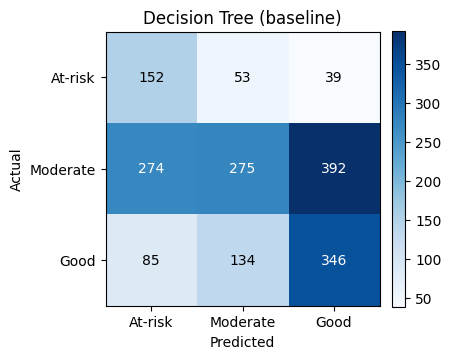

In [42]:
tree_pipe = Pipeline([
    ("preprocess", build_supervised_preprocessor()),
    ("model", DecisionTreeClassifier(max_depth=8, class_weight="balanced", random_state=RANDOM_STATE)),
])
tree_pipe.fit(X_train, y_train)
cms["Decision Tree"] = evaluate("Decision Tree (baseline)", tree_pipe, X_test, y_test, results)
plot_confusion(cms["Decision Tree"], "Decision Tree (baseline)")



------------------------------------------------------------
A. Bagging (200 trees, all features)
------------------------------------------------------------
Accuracy:        0.5503
Macro Precision: 0.5157
Macro Recall:    0.4163
Macro F1:        0.4201
Weighted F1:     0.5078

Classification report:
              precision    recall  f1-score   support

     At-risk       0.46      0.15      0.23       244
        Good       0.52      0.28      0.37       565
    Moderate       0.56      0.81      0.66       941

    accuracy                           0.55      1750
   macro avg       0.52      0.42      0.42      1750
weighted avg       0.54      0.55      0.51      1750

Confusion matrix (rows=actual, cols=predicted), order = ['At-risk', 'Moderate', 'Good']
[[ 37 196  11]
 [ 40 766 135]
 [  3 402 160]]


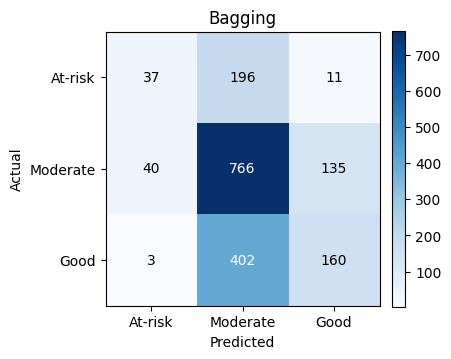

In [43]:
bagging_pipe = Pipeline([
    ("preprocess", build_supervised_preprocessor()),
    ("model", BaggingClassifier(
        estimator=DecisionTreeClassifier(class_weight="balanced", random_state=RANDOM_STATE),
        n_estimators=200,      
        max_samples=1.0,       
        max_features=1.0,      
        bootstrap=True,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    )),
])
t0 = time.time()
bagging_pipe.fit(X_train, y_train)
bagging_time = time.time() - t0
cms["Bagging"] = evaluate("A. Bagging (200 trees, all features)", bagging_pipe, X_test, y_test, results)
plot_confusion(cms["Bagging"], "Bagging")



------------------------------------------------------------
B. Random Forest (300 trees)
------------------------------------------------------------
Accuracy:        0.5549
Macro Precision: 0.5622
Macro Recall:    0.3902
Macro F1:        0.3725
Weighted F1:     0.4838

Classification report:
              precision    recall  f1-score   support

     At-risk       0.60      0.07      0.13       244
        Good       0.53      0.21      0.30       565
    Moderate       0.56      0.89      0.68       941

    accuracy                           0.55      1750
   macro avg       0.56      0.39      0.37      1750
weighted avg       0.55      0.55      0.48      1750

Confusion matrix (rows=actual, cols=predicted), order = ['At-risk', 'Moderate', 'Good']
[[ 18 216  10]
 [ 11 834  96]
 [  1 445 119]]


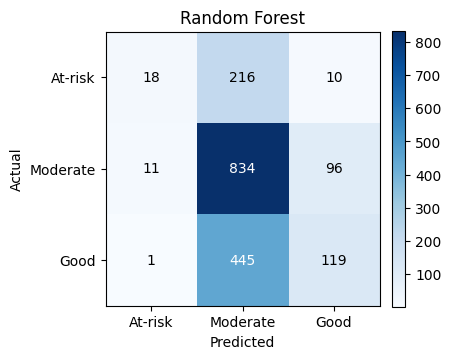

In [44]:
rf_pipe = Pipeline([
    ("preprocess", build_supervised_preprocessor()),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=None,          
        max_features="sqrt",      
        class_weight="balanced",  
        n_jobs=-1,
        random_state=RANDOM_STATE,
    )),
])
t0 = time.time()
rf_pipe.fit(X_train, y_train)
rf_time = time.time() - t0
cms["Random Forest"] = evaluate("B. Random Forest (300 trees)", rf_pipe, X_test, y_test, results)
plot_confusion(cms["Random Forest"], "Random Forest")


Random Forest feature importance (top 15):
numeric__daily_screen_hours                     0.142730
numeric__daily_notifications                    0.085724
numeric__avg_sleep_hours                        0.065880
numeric__minutes_to_first_check_after_waking    0.058603
numeric__age                                    0.056315
numeric__fomo_1to10                             0.048413
numeric__loneliness_1to10                       0.041792
numeric__social_comparison_1to10                0.041530
numeric__self_esteem_1to10                      0.039862
numeric__life_satisfaction_1to10                0.039432
numeric__platforms_used_count                   0.037578
numeric__physical_activity_days_per_week        0.033471
ordinal__night_time_use                         0.027285
ordinal__attempted_digital_detox                0.019781
ordinal__seeks_mental_health_support            0.018336
dtype: float64


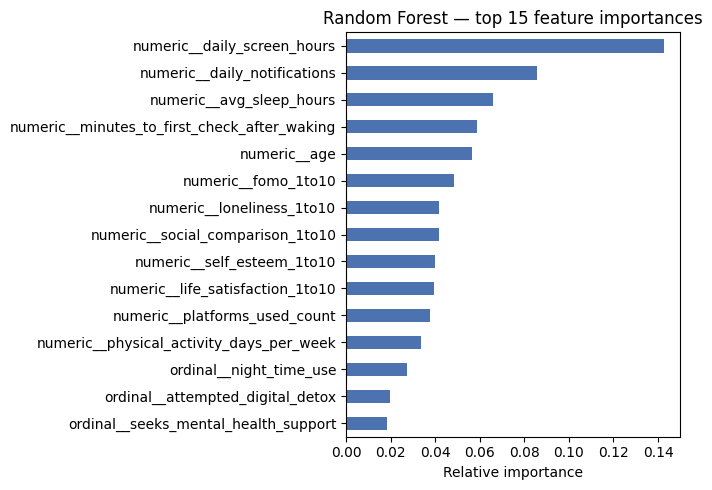

In [45]:
fitted_pre = rf_pipe.named_steps["preprocess"]
feature_names = fitted_pre.get_feature_names_out()
importances = rf_pipe.named_steps["model"].feature_importances_
imp_series = pd.Series(importances, index=feature_names).sort_values(ascending=False)

print("Random Forest feature importance (top 15):")
print(imp_series.head(15))

fig, ax = plt.subplots(figsize=(7, 5))
imp_series.head(15)[::-1].plot(kind="barh", ax=ax, color="#4C72B0")
ax.set_xlabel("Relative importance"); ax.set_title("Random Forest — top 15 feature importances")
fig.tight_layout()
plt.show()



------------------------------------------------------------
D. AdaBoost (200 stumps)
------------------------------------------------------------
Accuracy:        0.5526
Macro Precision: 0.5501
Macro Recall:    0.4318
Macro F1:        0.4441
Weighted F1:     0.5165

Classification report:
              precision    recall  f1-score   support

     At-risk       0.59      0.20      0.30       244
        Good       0.50      0.29      0.37       565
    Moderate       0.56      0.80      0.66       941

    accuracy                           0.55      1750
   macro avg       0.55      0.43      0.44      1750
weighted avg       0.55      0.55      0.52      1750

Confusion matrix (rows=actual, cols=predicted), order = ['At-risk', 'Moderate', 'Good']
[[ 50 183  11]
 [ 34 753 154]
 [  1 400 164]]


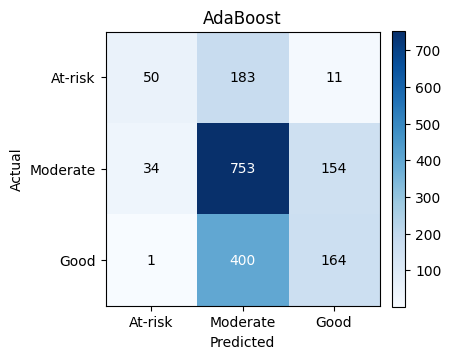

In [46]:
ada_pipe = Pipeline([
    ("preprocess", build_supervised_preprocessor()),
    ("model", AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE),  
        learning_rate=0.5, 
        random_state=RANDOM_STATE,
    )),
])
t0 = time.time()
ada_pipe.fit(X_train, y_train)
ada_time = time.time() - t0
cms["AdaBoost"] = evaluate("D. AdaBoost (200 stumps)", ada_pipe, X_test, y_test, results)
plot_confusion(cms["AdaBoost"], "AdaBoost")


In [47]:
for r, t in zip(results[1:], [bagging_time, rf_time, ada_time]):
    r["train_time_sec"] = round(t, 2)
results[0]["train_time_sec"] = None

comp_df = pd.DataFrame(results).set_index("model").round(4)
comp_df.to_csv(f"{OUT_DIR}/ensemble_comparison.csv")
comp_df


,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,train_time_sec
model,,,,,,
Decision Tree (baseline),0.4417,0.4460,0.5092,0.4368,0.4334,NaN
"A. Bagging (200 trees, all features)",0.5503,0.5157,0.4163,0.4201,0.5078,4.66
B. Random Forest (300 trees),0.5549,0.5622,0.3902,0.3725,0.4838,1.92
D. AdaBoost (200 stumps),0.5526,0.5501,0.4318,0.4441,0.5165,0.65


In [48]:
param_dist = {
    "model__n_estimators": [100, 200, 300, 400],
    "model__max_depth": [None, 8, 12, 16, 20],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 3, 5],
    "model__max_features": ["sqrt", "log2", 0.5],
}

search = RandomizedSearchCV(
    estimator=Pipeline([
        ("preprocess", build_supervised_preprocessor()),
        ("model", RandomForestClassifier(class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE)),
    ]),
    param_distributions=param_dist,
    n_iter=20,
    scoring="f1_macro",
    cv=5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
search.fit(X_train, y_train)
print(f"Best CV macro-F1: {search.best_score_:.4f}")
print(f"Best params: {search.best_params_}")

tuned_pipe = search.best_estimator_
cms["Random Forest (tuned)"] = evaluate("Random Forest — TUNED", tuned_pipe, X_test, y_test, results)

comp_df_final = pd.DataFrame(results).set_index("model").round(4)
comp_df_final.to_csv(f"{OUT_DIR}/ensemble_comparison_with_tuned.csv")
comp_df_final


Best CV macro-F1: 0.4935
Best params: {'model__n_estimators': 300, 'model__min_samples_split': 5, 'model__min_samples_leaf': 1, 'model__max_features': 0.5, 'model__max_depth': 12}

------------------------------------------------------------
Random Forest — TUNED
------------------------------------------------------------
Accuracy:        0.5337
Macro Precision: 0.5009
Macro Recall:    0.4860
Macro F1:        0.4920
Weighted F1:     0.5319

Classification report:
              precision    recall  f1-score   support

     At-risk       0.43      0.35      0.39       244
        Good       0.49      0.51      0.50       565
    Moderate       0.58      0.59      0.59       941

    accuracy                           0.53      1750
   macro avg       0.50      0.49      0.49      1750
weighted avg       0.53      0.53      0.53      1750

Confusion matrix (rows=actual, cols=predicted), order = ['At-risk', 'Moderate', 'Good']
[[ 86 133  25]
 [102 559 280]
 [ 11 265 289]]


,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,train_time_sec
model,,,,,,
Decision Tree (baseline),0.4417,0.4460,0.5092,0.4368,0.4334,NaN
"A. Bagging (200 trees, all features)",0.5503,0.5157,0.4163,0.4201,0.5078,4.66
B. Random Forest (300 trees),0.5549,0.5622,0.3902,0.3725,0.4838,1.92
D. AdaBoost (200 stumps),0.5526,0.5501,0.4318,0.4441,0.5165,0.65
Random Forest — TUNED,0.5337,0.5009,0.4860,0.4920,0.5319,NaN


In [49]:
CLUSTERING_NUMERIC_FEATURES = [
    "daily_screen_hours", "daily_notifications", "minutes_to_first_check_after_waking",
    "avg_sleep_hours", "platforms_used_count", "physical_activity_days_per_week",
    "life_satisfaction_1to10", "loneliness_1to10", "self_esteem_1to10",
    "fomo_1to10", "social_comparison_1to10",
]
CLUSTERING_ORDINAL_FEATURE = "night_time_use"
CLUSTERING_ORDINAL_ORDER = ["Never", "Sometimes", "Often", "Every night"]

X_cluster_raw = df[CLUSTERING_NUMERIC_FEATURES].copy()
X_cluster_raw[CLUSTERING_ORDINAL_FEATURE] = df[CLUSTERING_ORDINAL_FEATURE]

cluster_pre = ColumnTransformer([
    ("numeric", Pipeline([("impute", SimpleImputer(strategy="median"))]), CLUSTERING_NUMERIC_FEATURES),
    ("ordinal", Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("encode", OrdinalEncoder(categories=[CLUSTERING_ORDINAL_ORDER])),
    ]), [CLUSTERING_ORDINAL_FEATURE]),
])
cluster_pipe_pre = Pipeline([("pre", cluster_pre), ("scale", StandardScaler())])
X_scaled = cluster_pipe_pre.fit_transform(X_cluster_raw)
print("Shape after preprocessing:", X_scaled.shape)


Shape after preprocessing: (7000, 12)


K=2: WCSS = 72024.8
K=3: WCSS = 67337.3
K=4: WCSS = 64510.1
K=5: WCSS = 62002.8
K=6: WCSS = 60000.6
K=7: WCSS = 58409.9
K=8: WCSS = 56971.2
K=9: WCSS = 55857.7
K=10: WCSS = 54884.5


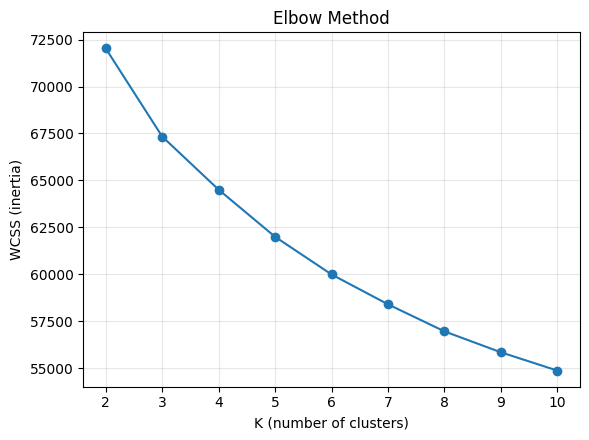

In [50]:
k_range = list(range(2, 11))
wcss_by_k = {}
kmeans_by_k = {}
for k in k_range:
    km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=RANDOM_STATE)
    km.fit(X_scaled)
    wcss_by_k[k] = km.inertia_  
    kmeans_by_k[k] = km
    print(f"K={k}: WCSS = {km.inertia_:.1f}")

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(k_range, [wcss_by_k[k] for k in k_range], marker="o")
ax.set_xlabel("K (number of clusters)"); ax.set_ylabel("WCSS (inertia)")
ax.set_title("Elbow Method"); ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()


TSS (fixed, independent of K): 84000.0

  K |       WCSS |       BCSS | BCSS/TSS
  2 |    72024.8 |    11975.2 | 0.143
  3 |    67337.3 |    16662.7 | 0.198
  4 |    64510.1 |    19489.9 | 0.232
  5 |    62002.8 |    21997.2 | 0.262
  6 |    60000.6 |    23999.4 | 0.286
  7 |    58409.9 |    25590.1 | 0.305
  8 |    56971.2 |    27028.8 | 0.322
  9 |    55857.7 |    28142.3 | 0.335
 10 |    54884.5 |    29115.5 | 0.347


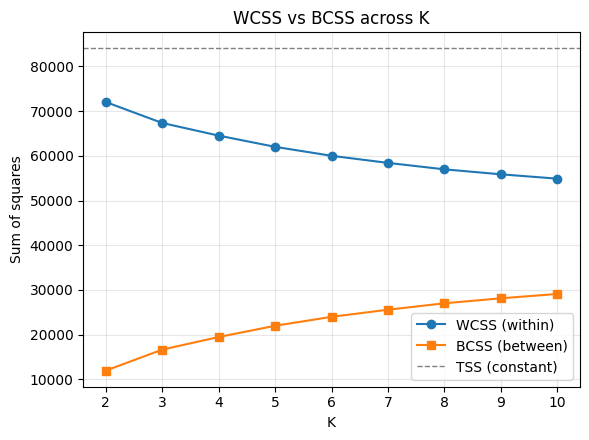

In [51]:
def compute_tss(X):
    grand_mean = X.mean(axis=0)
    return float(np.sum((X - grand_mean) ** 2))

tss = compute_tss(X_scaled)
bcss_by_k = {}
for k in k_range:
    bcss_by_k[k] = tss - wcss_by_k[k]
    assert abs((wcss_by_k[k] + bcss_by_k[k]) - tss) < 1e-6 
print(f"TSS (fixed, independent of K): {tss:.1f}\n")
print(f"{'K':>3} | {'WCSS':>10} | {'BCSS':>10} | BCSS/TSS")
for k in k_range:
    print(f"{k:>3} | {wcss_by_k[k]:>10.1f} | {bcss_by_k[k]:>10.1f} | {bcss_by_k[k]/tss:.3f}")

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(k_range, [wcss_by_k[k] for k in k_range], marker="o", label="WCSS (within)")
ax.plot(k_range, [bcss_by_k[k] for k in k_range], marker="s", label="BCSS (between)")
ax.axhline(tss, color="gray", linestyle="--", linewidth=1, label="TSS (constant)")
ax.set_xlabel("K"); ax.set_ylabel("Sum of squares"); ax.set_title("WCSS vs BCSS across K")
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()


In [52]:
K_COMPARE = 4
n_seeds = 15
random_final_wcss, plusplus_final_wcss = [], []
for seed in range(n_seeds):
    km_r = KMeans(n_clusters=K_COMPARE, init="random", n_init=1, random_state=seed).fit(X_scaled)
    km_p = KMeans(n_clusters=K_COMPARE, init="k-means++", n_init=1, random_state=seed).fit(X_scaled)
    random_final_wcss.append(km_r.inertia_)
    plusplus_final_wcss.append(km_p.inertia_)

print(f"Across {n_seeds} seeds, K={K_COMPARE}, n_init=1 (single run each, to expose init sensitivity):")
print(f"  random init -> mean WCSS = {np.mean(random_final_wcss):.1f}, std = {np.std(random_final_wcss):.1f}, worst = {np.max(random_final_wcss):.1f}")
print(f"  k-means++   -> mean WCSS = {np.mean(plusplus_final_wcss):.1f}, std = {np.std(plusplus_final_wcss):.1f}, worst = {np.max(plusplus_final_wcss):.1f}")


Across 15 seeds, K=4, n_init=1 (single run each, to expose init sensitivity):
  random init -> mean WCSS = 64599.4, std = 102.2, worst = 64899.2
  k-means++   -> mean WCSS = 64612.4, std = 104.4, worst = 64904.2


K=2: silhouette = 0.1517
K=3: silhouette = 0.0937
K=4: silhouette = 0.0915
K=5: silhouette = 0.0837
K=6: silhouette = 0.0799
K=7: silhouette = 0.0715
K=8: silhouette = 0.0693
K=9: silhouette = 0.0666
K=10: silhouette = 0.0647


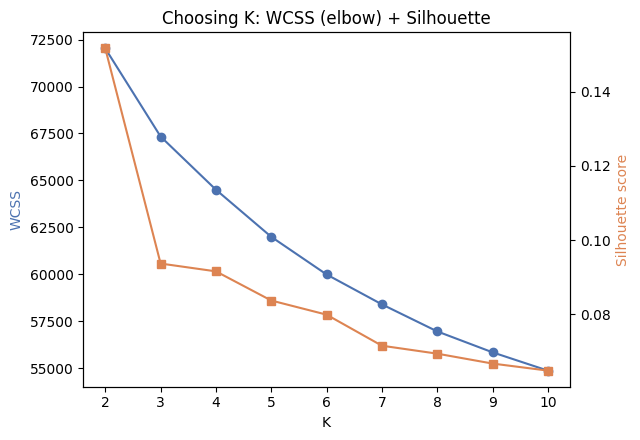


Silhouette peaks at K=2


In [53]:
rng = np.random.RandomState(RANDOM_STATE)
sample_idx = rng.choice(X_scaled.shape[0], size=min(2000, X_scaled.shape[0]), replace=False)

sil_by_k = {}
for k in k_range:
    labels = kmeans_by_k[k].predict(X_scaled)
    sil_by_k[k] = silhouette_score(X_scaled[sample_idx], labels[sample_idx])
    print(f"K={k}: silhouette = {sil_by_k[k]:.4f}")

fig, ax1 = plt.subplots(figsize=(6.5, 4.5))
ax1.plot(k_range, [wcss_by_k[k] for k in k_range], marker="o", color="#4C72B0", label="WCSS")
ax1.set_xlabel("K"); ax1.set_ylabel("WCSS", color="#4C72B0")
ax2 = ax1.twinx()
ax2.plot(k_range, [sil_by_k[k] for k in k_range], marker="s", color="#DD8452", label="Silhouette")
ax2.set_ylabel("Silhouette score", color="#DD8452")
ax1.set_title("Choosing K: WCSS (elbow) + Silhouette")
fig.tight_layout()
plt.show()

best_k_by_silhouette = max(sil_by_k, key=sil_by_k.get)
print(f"\nSilhouette peaks at K={best_k_by_silhouette}")


Variance captured by the 2 PCA axes: 22.4% + 11.1% = 33.5%


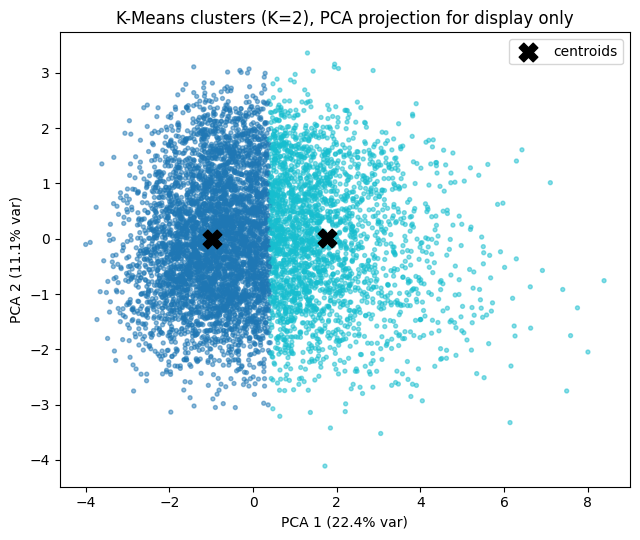

In [54]:
FINAL_K = best_k_by_silhouette
final_km = kmeans_by_k[FINAL_K]
final_labels = final_km.labels_

pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(X_scaled)
explained = pca.explained_variance_ratio_
print(f"Variance captured by the 2 PCA axes: {explained[0]:.1%} + {explained[1]:.1%} = {sum(explained):.1%}")

fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.scatter(coords[:, 0], coords[:, 1], c=final_labels, cmap="tab10", s=8, alpha=0.5)
centroids_pca = pca.transform(final_km.cluster_centers_)
ax.scatter(centroids_pca[:, 0], centroids_pca[:, 1], c="black", marker="X", s=180, label="centroids")
ax.set_xlabel(f"PCA 1 ({explained[0]:.1%} var)"); ax.set_ylabel(f"PCA 2 ({explained[1]:.1%} var)")
ax.set_title(f"K-Means clusters (K={FINAL_K}), PCA projection for display only")
ax.legend()
fig.tight_layout()
plt.show()


In [55]:
profile_df = X_cluster_raw.copy()
profile_df["cluster"] = final_labels
sizes = profile_df["cluster"].value_counts().sort_index()
print("Cluster sizes:")
for c, n in sizes.items():
    print(f"  Cluster {c}: {n} people ({n/len(profile_df):.1%})")

means = profile_df.groupby("cluster")[CLUSTERING_NUMERIC_FEATURES].mean().round(2)
means.to_csv(f"{OUT_DIR}/cluster_profiles.csv")
print("\nMean feature values per cluster:")
means.T


Cluster sizes:
  Cluster 0: 4507 people (64.4%)
  Cluster 1: 2493 people (35.6%)

Mean feature values per cluster:


cluster,0,1
daily_screen_hours,2.32,5.09
daily_notifications,39.52,101.32
minutes_to_first_check_after_waking,20.08,19.87
avg_sleep_hours,7.26,6.43
platforms_used_count,3.55,3.39
physical_activity_days_per_week,2.80,2.82
life_satisfaction_1to10,7.44,6.08
loneliness_1to10,4.12,5.69
self_esteem_1to10,6.46,5.19
fomo_1to10,3.97,5.85


In [56]:
overall_means = X_cluster_raw[CLUSTERING_NUMERIC_FEATURES].mean()
for c in sorted(profile_df["cluster"].unique()):
    diffs = (means.loc[c] - overall_means).sort_values(ascending=False)
    print(f"Cluster {c} (n={sizes[c]}): HIGHER {diffs.head(2).index.tolist()}, "
          f"LOWER {diffs.tail(2).index.tolist()}, relative to the overall average.")


Cluster 0 (n=4507): HIGHER ['life_satisfaction_1to10', 'self_esteem_1to10'], LOWER ['daily_screen_hours', 'daily_notifications'], relative to the overall average.
Cluster 1 (n=2493): HIGHER ['daily_notifications', 'daily_screen_hours'], LOWER ['self_esteem_1to10', 'life_satisfaction_1to10'], relative to the overall average.


In [57]:
crosstab = pd.crosstab(profile_df["cluster"], df.loc[profile_df.index, "wellbeing_band"], normalize="index").round(3)
crosstab = crosstab[["At-risk", "Moderate", "Good"]]
crosstab.to_csv(f"{OUT_DIR}/cluster_vs_wellbeing_band.csv")
crosstab


wellbeing_band,At-risk,Moderate,Good
cluster,,,
0,0.059,0.526,0.415
1,0.284,0.560,0.156


In [58]:
K_NARRATIVE = 4
narrative_km = kmeans_by_k[K_NARRATIVE]
narrative_profile = X_cluster_raw.copy()
narrative_profile["cluster"] = narrative_km.labels_
narrative_means = narrative_profile.groupby("cluster")[CLUSTERING_NUMERIC_FEATURES].mean().round(2)
narrative_means.to_csv(f"{OUT_DIR}/cluster_profiles_k4_narrative.csv")
print("Sizes:", dict(narrative_profile["cluster"].value_counts().sort_index()))
narrative_means.T


Sizes: {0: np.int64(938), 1: np.int64(2010), 2: np.int64(2435), 3: np.int64(1617)}


cluster,0,1,2,3
daily_screen_hours,2.82,2.74,2.33,5.76
daily_notifications,46.62,47.81,40.12,119.46
minutes_to_first_check_after_waking,44.64,15.92,14.99,18.35
avg_sleep_hours,7.15,6.51,7.63,6.44
platforms_used_count,3.41,3.60,3.54,3.35
physical_activity_days_per_week,2.82,2.74,2.84,2.82
life_satisfaction_1to10,7.13,6.96,7.59,5.90
loneliness_1to10,4.73,4.29,4.15,5.93
self_esteem_1to10,5.98,6.14,6.54,5.06
fomo_1to10,4.47,4.28,3.95,6.24


In [59]:
from sklearn.base import clone

final_pipeline = clone(search.best_estimator_)
final_pipeline.fit(X, y)
print(f"Final pipeline fit on all {len(X)} rows.")

MODEL_PATH = os.path.join(OUT_DIR, "wellbeing_pipeline.joblib")
joblib.dump(final_pipeline, MODEL_PATH)
print(f"Saved to {MODEL_PATH}")


Final pipeline fit on all 7000 rows.
Saved to /kaggle/working/wellbeing_pipeline.joblib


In [60]:
reloaded = joblib.load(MODEL_PATH)
sample = X.iloc[[0]]
pred = reloaded.predict(sample)
proba = reloaded.predict_proba(sample)
print(f"Reloaded pipeline predicts on row 0: {pred[0]}")
print(f"Probabilities: {dict(zip(reloaded.classes_, proba[0].round(3)))}")


Reloaded pipeline predicts on row 0: At-risk
Probabilities: {'At-risk': np.float64(0.6), 'Good': np.float64(0.153), 'Moderate': np.float64(0.248)}
